In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Preprocessing for IRIS Dataset

This notebook performs data preprocessing on the IRIS dataset, including outlier detection and removal, and correlation analysis.

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load the dataset
df = pd.read_csv('IRIS.csv')

## Outlier Detection and Visualization

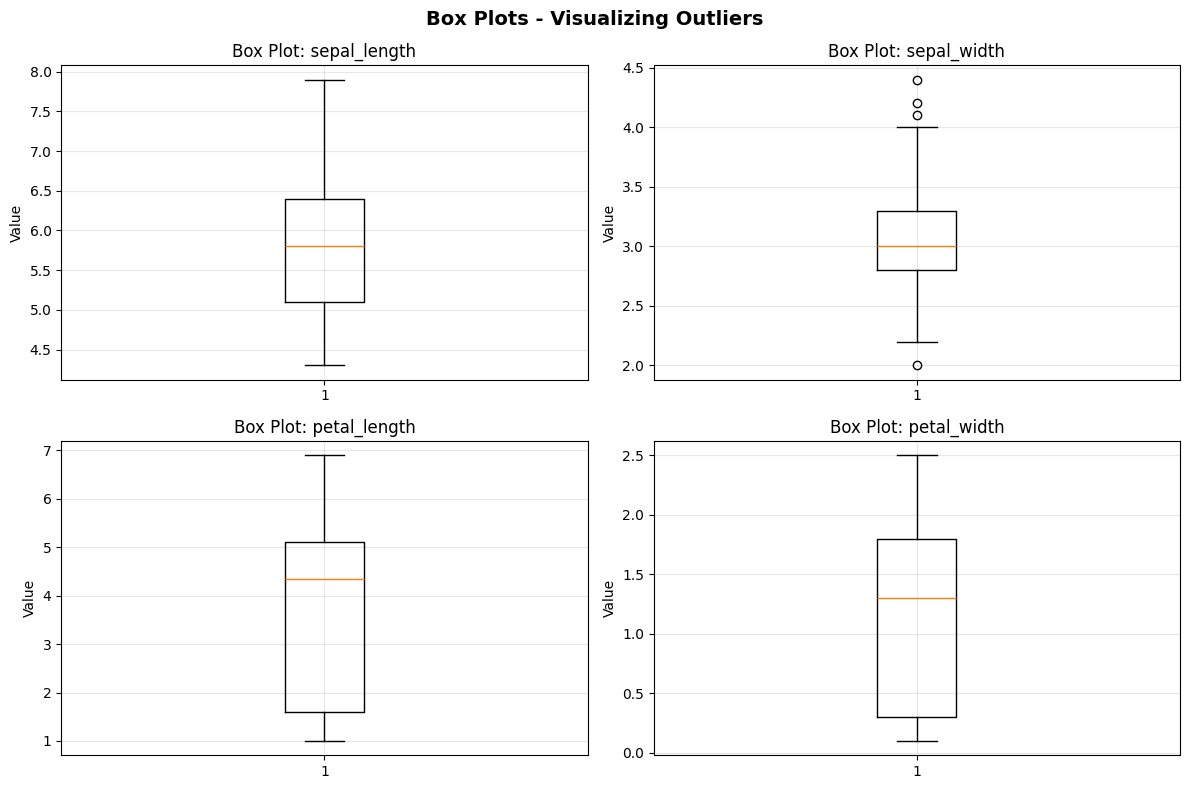

In [6]:
# Create box plots to visualize outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Box Plots - Visualizing Outliers', fontsize=14, fontweight='bold')

numeric_cols = df.select_dtypes(include=[np.number]).columns
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 2, idx % 2]
    ax.boxplot(df[col], vert=True)
    ax.set_title(f'Box Plot: {col}')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Display quartiles and IQR information
print("Quartile and IQR Information:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"\n{col}:")
    print(f"  Q1 (25%): {Q1:.4f}")
    print(f"  Q3 (75%): {Q3:.4f}")
    print(f"  IQR: {IQR:.4f}")

Quartile and IQR Information:

sepal_length:
  Q1 (25%): 5.1000
  Q3 (75%): 6.4000
  IQR: 1.3000

sepal_width:
  Q1 (25%): 2.8000
  Q3 (75%): 3.3000
  IQR: 0.5000

petal_length:
  Q1 (25%): 1.6000
  Q3 (75%): 5.1000
  IQR: 3.5000

petal_width:
  Q1 (25%): 0.3000
  Q3 (75%): 1.8000
  IQR: 1.5000


## Outlier Removal using IQR Method

In [8]:
# Function to remove outliers using IQR method
def remove_outliers_iqr(data, columns):
    """Remove outliers using the IQR method"""
    df_clean = data.copy()
    outliers_removed = 0
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers before removing
        outliers_in_col = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        outliers_removed += outliers_in_col
        
        # Remove outliers
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        
        print(f"{col}:")
        print(f"  Lower Bound: {lower_bound:.4f}")
        print(f"  Upper Bound: {upper_bound:.4f}")
        print(f"  Outliers found: {outliers_in_col}")
    
    return df_clean, outliers_removed

In [9]:
# Apply IQR method to remove outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_clean, total_outliers = remove_outliers_iqr(df, numeric_cols)

print("\n" + "="*50)
print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_clean.shape}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]}")

sepal_length:
  Lower Bound: 3.1500
  Upper Bound: 8.3500
  Outliers found: 0
sepal_width:
  Lower Bound: 2.0500
  Upper Bound: 4.0500
  Outliers found: 4
petal_length:
  Lower Bound: -3.6500
  Upper Bound: 10.3500
  Outliers found: 0
petal_width:
  Lower Bound: -1.9500
  Upper Bound: 4.0500
  Outliers found: 0

Original dataset shape: (150, 5)
Dataset shape after outlier removal: (146, 5)
Total rows removed: 4


## Correlation Analysis

In [10]:
# Compute correlation matrix
correlation_matrix = df_clean.corr(numeric_only=True)

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.113977      0.879374     0.822577
sepal_width      -0.113977     1.000000     -0.397123    -0.329782
petal_length      0.879374    -0.397123      1.000000     0.961755
petal_width       0.822577    -0.329782      0.961755     1.000000


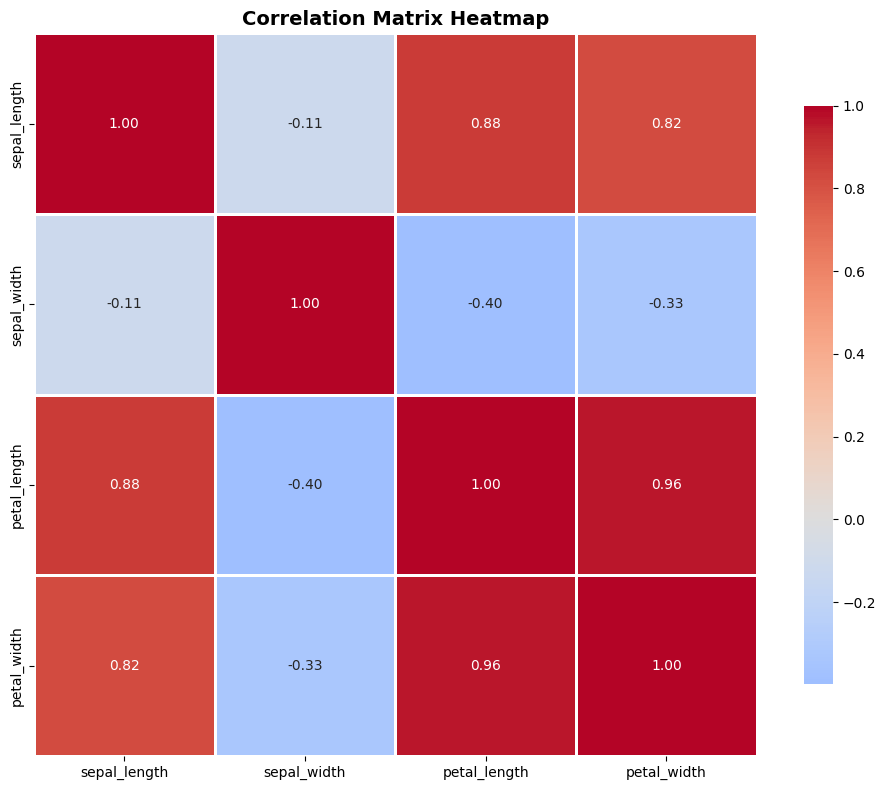

In [11]:
# Create a heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Display correlations with target variable (species)
print("Feature Correlations (Numeric features only):")
print(correlation_matrix.iloc[:, :-1])

Feature Correlations (Numeric features only):
              sepal_length  sepal_width  petal_length
sepal_length      1.000000    -0.113977      0.879374
sepal_width      -0.113977     1.000000     -0.397123
petal_length      0.879374    -0.397123      1.000000
petal_width       0.822577    -0.329782      0.961755
